In [1]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import set_config
set_config(transform_output="pandas")

df = pd.read_excel("../data/moscow_transformed.xlsx").set_index(["ID на сайте", "Источник"])
df = df[["Цена", "lat", "lng", "Общая площадь", "Расстояние до метро, км", "Этаж", "Тип автора", "Вид объекта", "Метро/Район"]].copy()
df.columns = ["price", "lat", "lon", "square", "metro_dist", "floor", "author_type", "object_type", "metro_district"]
df = df.dropna(subset="object_type")
df.head()

,,price,lat,lon,square,metro_dist,floor,author_type,object_type,metro_district
ID на сайте,Источник,,,,,,,,,
320731003,cian.ru,38800,55.621211,37.745600,25.0,0.083,4.0,Агентство,Офисное помещение,Шипиловская
321876001,cian.ru,31250,55.799036,37.532601,25.0,0.250,-2.0,Агентство,Офисное помещение,Аэропорт
322186790,cian.ru,29200,55.731176,37.669279,20.0,0.250,6.0,Агентство,Офисное помещение,Пролетарская
321392086,cian.ru,32000,55.540409,37.516153,32.0,0.250,3.0,Частное лицо,Торговое / Свободного назначения,Бунинская Аллея
324943206,cian.ru,44000,55.808002,37.635853,24.0,0.167,14.0,Агентство,Офисное помещение,Алексеевская


In [2]:
df.dtypes

price               int64
lat               float64
lon               float64
square            float64
metro_dist        float64
floor             float64
author_type        object
object_type        object
metro_district     object
dtype: object

In [3]:
df.isna().sum()

price               0
lat                 0
lon                 0
square              0
metro_dist          0
floor             123
author_type         0
object_type         0
metro_district      0
dtype: int64

In [4]:
df["metro_district"].nunique()

315

In [5]:
from sklearn.model_selection import train_test_split

y = df["price"].copy()
df = df.drop("price", axis=1)

df_train, df_test, y_train, y_test = train_test_split(df, y, test_size=0.25, stratify=df["object_type"])

In [6]:
df_train["floor"] = df_train["floor"].fillna(1)
df_test["floor"] = df_test["floor"].fillna(1)

# Pipeline

In [7]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


class OrdinalByTargetEncoder(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.te = TargetEncoder(target_type="continuous", random_state=10)

    def fit(self, X, y):
        self.te = self.te.fit(X, y)
        
    def transform(self, X, y=None):
        X_copy = X.copy()
        for i, col in enumerate(X.columns):
            cat_dict = dict(zip(self.te.categories_[i], self.te.encodings_[i]))
            ordinal_categories = sorted(cat_dict, key=cat_dict.get)
            ordinal_mapping = dict(zip(ordinal_categories, range(len(ordinal_categories))))
            X_copy[col] = X_copy[col].map(ordinal_mapping)
            # Заполним пропуски центральным значением (медианой)
            X_copy[col] = X_copy[col].fillna(len(ordinal_categories) // 2)
        return X_copy

    def fit_transform(self, X, y):
        self.fit(X, y)
        return self.transform(X)

    def set_output(self, *, transform=None):
        """Scikit-learn 1.2+ requirement"""
        return self


def make_transformer(
            scale_cols: list,
            one_hot_cols: list,
            ordinal_cols: list,
            **kwargs
    ):
    ct = ColumnTransformer(
        transformers=[
            ("scale", StandardScaler(), scale_cols),
            ("onehot", OneHotEncoder(drop="if_binary", sparse_output=False), one_hot_cols),
            ("ordinal", OrdinalByTargetEncoder(), ordinal_cols),
        ],
        **kwargs
    ).set_output(transform="pandas")
    return ct

def make_pipeline(
        model,
        scale_cols: list,
        one_hot_cols: list,
        ordinal_cols: list,
        **kwargs
    ):

    ct = make_transformer(scale_cols, one_hot_cols, ordinal_cols, **kwargs)

    pipe = Pipeline(
        steps=[
            ("transformer", ct),
            ("model", model),
        ]
    )

    return pipe

# Модель

In [8]:
from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso, QuantileRegressor
)

from sklearn.metrics import (
    r2_score,
    root_mean_squared_error as rmse,
    mean_absolute_percentage_error as mape,
)

def print_metrics(y_true, y_pred, dataset):
    print(f"{dataset} metrics:")
    print(f"\t  R2: {r2_score(y_true, y_pred) * 100:.2f}%")
    print(f"\tRMSE: {rmse(y_true, y_pred):.2f} руб.")
    print(f"\tMAPE: {mape(y_true, y_pred) * 100:.2f}%")

In [9]:
import sys
sys.path.append("..")

import viz

## Линейка

In [10]:
scale_cols = ["square", "metro_dist", "floor"]
one_hot_cols = ["object_type", "author_type"]
ordinal_cols = ["metro_district"]

linear_pipe = make_pipeline(
    LinearRegression(),
    scale_cols, one_hot_cols, ordinal_cols,
    remainder="passthrough", n_jobs=-1)

linear_pipe

,steps,"[('transformer', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('scale', ...), ('onehot', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,-1
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


train metrics:
	  R2: 73.07%
	RMSE: 748289.76 руб.
	MAPE: 91.98%

test metrics:
	  R2: 72.84%
	RMSE: 742280.13 руб.
	MAPE: 96.68%


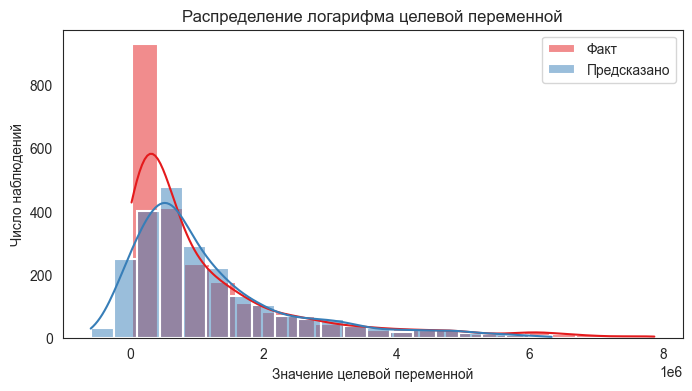

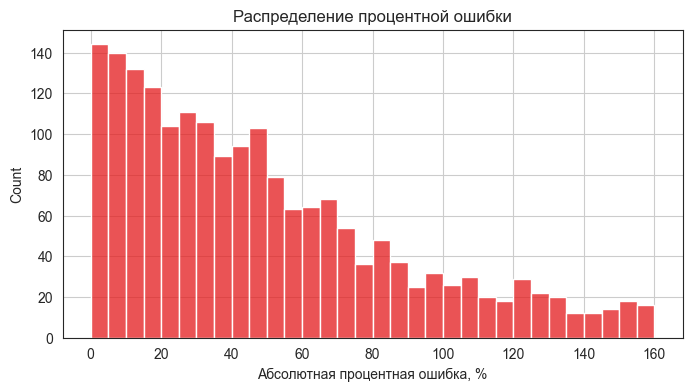

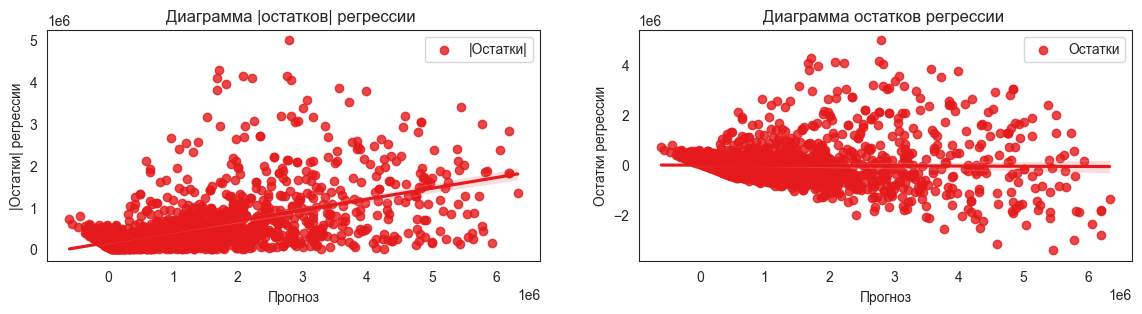

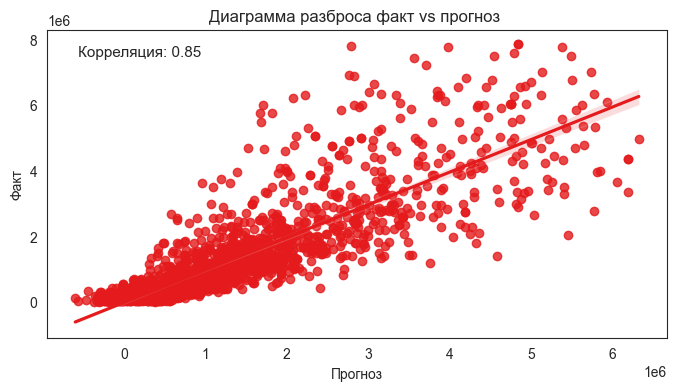

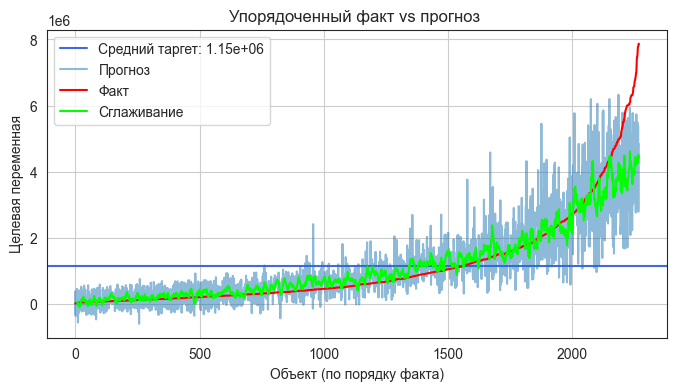

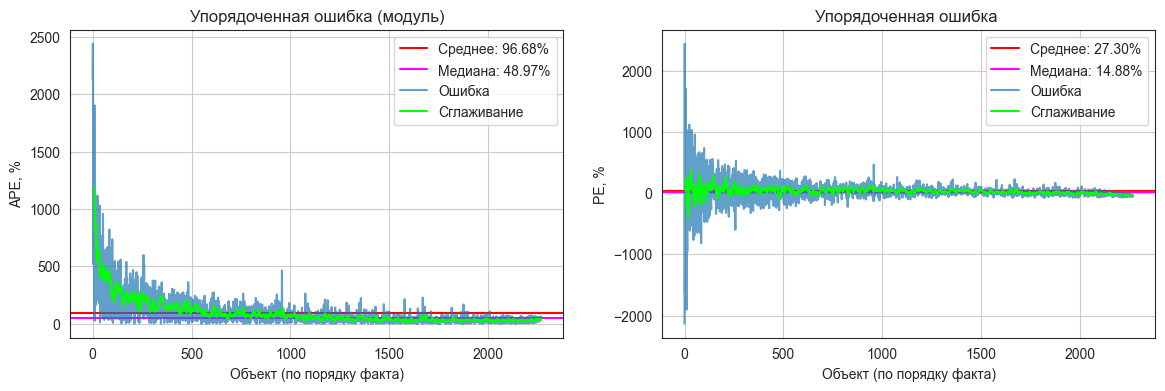

In [11]:
model = linear_pipe.fit(df_train, y_train)
y_pred = model.predict(df_train)
y_test_pred = model.predict(df_test)

print_metrics(y_train, y_pred, "train")
print()
print_metrics(y_test, y_test_pred, "test")

viz.plot_target_hist(y_test, y_test_pred)
viz.plot_ape_bins(y_test, y_test_pred)
viz.plot_regression_residuals(y_test, y_test_pred)
viz.plot_scatter(y_test, y_test_pred)
viz.plot_predict_sorted(y_test.values, y_test_pred, window=10)
viz.plot_ape_sorted(y_test.values, y_test_pred, window=10)

In [13]:
# from dotenv import load_dotenv

# load_dotenv()

Name: python-dotenv
Version: 1.2.1
Summary: Read key-value pairs from a .env file and set them as environment variables
Home-page: 
Author: 
Author-email: Saurabh Kumar <me+github@saurabh-kumar.com>
License-Expression: BSD-3-Clause
Location: c:\users\oleg\miniconda3\envs\sirius\lib\site-packages
Requires: 
Required-by: dotenv, litellm, mcpadapt, pydantic-settings, smolagents
